# Bio-Orbit Labs — Visão Computacional (ACV) · MARCO · v3
## Classificação de resultados de cristalização de proteína (dataset real)

**Global Solution 2026 · Indústria Espacial · Engenharia de Software 4º ano — FIAP**

**Integrantes (preencher):** Sofia Coutinho – RM552534 · Anna Yagyu – RM550360 · Felipe Capriotti - RM98460 · Gustavo Kawamura - RM99679 · Gabriel Pacheco - RM550191

Duas CNNs **treinadas do zero** (sem modelos pré-treinados) classificam imagens
**reais** do dataset **MARCO** nas 4 classes normalizadas: `Clear`, `Crystals`,
`Other`, `Precipitate`.

> ⚙️ Colab → GPU → `Executar tudo`. **Treino leva em cerca de (~30–50 min):**
> usa 30 mil imagens, 35 épocas e agendamento de learning rate para extrair o
> máximo de um modelo treinado do zero.

## 1. Problema e conexão com a Indústria Espacial

Empresas farmacêuticas cultivam cristais de proteína na ISS e em minissatélites
porque a microgravidade gera cristais mais perfeitos. Avaliar visualmente cada
gota consome banda de telemetria cara. **Nossa solução (Edge Laboratory Computing)**
roda a triagem visual a bordo: a CNN classifica o resultado e envia à Terra apenas
o rótulo + alerta. **ODS:** 9 (Inovação) e 3 (Saúde e bem-estar).

**Dificuldade (essencial para a análise):** dado real e ruidoso — a concordância
entre crystallographers humanos é de aproximadamente **70% (≈93% só para cristais)**, e os melhores
resultados publicados (~94%) usaram redes **pré-treinadas** e dezenas de GPUs.

In [1]:
# ============================================================
# Imports e configuração
# ============================================================
import os, time, math, collections, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED=42; np.random.seed(SEED); tf.random.set_seed(SEED)
IMG=128; BATCH=64; EPOCHS=35
N_TRAIN=20000; N_VAL=4000; N_TEST=4000

# Ordem = índice do rótulo normalizado do MARCO: 0=Clear, 1=Crystals, 2=Other, 3=Precipitate
CLASSES=['Clear','Crystals','Other','Precipitate']
print('TensorFlow', tf.__version__, '| GPU:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow 2.20.0 | GPU: True


## 2. Download do dataset MARCO (subconjunto Kaggle, formato TFRecords)

In [2]:
# !pip install kagglehub -q
import kagglehub
DATA_PATH = kagglehub.dataset_download("grantwiersum/marco-protein-crystal-image-recognition")
print('Baixado em:', DATA_PATH)

Using Colab cache for faster access to the 'marco-protein-crystal-image-recognition' dataset.
Baixado em: /kaggle/input/marco-protein-crystal-image-recognition


### 2.1 Localização dos arquivos TFRecord (com diagnóstico)

In [3]:
all_files = [os.path.join(dp,f) for dp,_,fs in os.walk(DATA_PATH) for f in fs]
print('Maiores arquivos:')
for p in sorted(all_files, key=os.path.getsize, reverse=True)[:12]:
    print(f'   {os.path.getsize(p)/1e6:8.1f} MB  {os.path.relpath(p, DATA_PATH)}')
print('Total de arquivos:', len(all_files))

def is_tfr(p):
    return os.path.getsize(p) > 100_000 and not p.lower().endswith(
        ('.csv','.txt','.md','.json','.html','.zip','.gz','.jpg','.jpeg','.png','.pdf'))
tfr = [p for p in all_files if is_tfr(p)]
train_files = [p for p in tfr if 'train' in p.lower()]
test_files  = [p for p in tfr if ('test' in p.lower() or 'val' in p.lower())]
if not train_files and not test_files:
    s = sorted(tfr); k = int(0.85*len(s)); train_files, test_files = s[:k], s[k:]
elif not test_files:
    k = max(1, len(train_files)//6); test_files = train_files[:k]; train_files = train_files[k:]
val_files = train_files[:max(1, len(train_files)//6)]
trn_files = train_files[len(val_files):]
print(f'\nTFRecords -> treino: {len(trn_files)} | validação: {len(val_files)} | teste: {len(test_files)}')
assert trn_files and test_files, 'Não localizei TFRecords — me mande a lista impressa acima.'

Maiores arquivos:
      153.2 MB  train-00007-of-00407
      152.5 MB  test-00001-of-00046
      151.6 MB  train-00011-of-00407
      151.6 MB  test-00002-of-00046
      151.0 MB  train-00012-of-00407
      150.4 MB  train-00003-of-00407
      150.2 MB  test-00003-of-00046
      149.6 MB  train-00005-of-00407
      148.6 MB  train-00009-of-00407
      148.2 MB  train-00002-of-00407
      148.0 MB  train-00006-of-00407
      147.1 MB  train-00001-of-00407
Total de arquivos: 15

TFRecords -> treino: 10 | validação: 2 | teste: 3


### 2.2 Pipeline de leitura

In [4]:
feat = {'image/encoded': tf.io.FixedLenFeature([], tf.string),
        'image/class/label': tf.io.FixedLenFeature([], tf.int64)}
def parse(proto):
    e = tf.io.parse_single_example(proto, feat)
    img = tf.io.decode_jpeg(e['image/encoded'], channels=3)
    img = tf.image.resize(img, (IMG, IMG))          # mantém uint8 (4x menos RAM que float)
    return tf.cast(img, tf.uint8), tf.cast(e['image/class/label'], tf.int32)

# Pipeline enxuto p/ não estourar RAM: paralelismo limitado, shuffle pequeno, prefetch fixo
ds_train = (tf.data.TFRecordDataset(trn_files, num_parallel_reads=4)
            .shuffle(2000, seed=SEED).take(N_TRAIN)
            .map(parse, num_parallel_calls=4).batch(BATCH).prefetch(2))
ds_val   = (tf.data.TFRecordDataset(val_files, num_parallel_reads=4)
            .take(N_VAL).map(parse, num_parallel_calls=4).batch(BATCH).cache().prefetch(2))
ds_test  = (tf.data.TFRecordDataset(test_files, num_parallel_reads=4)
            .take(N_TEST).map(parse, num_parallel_calls=4).batch(BATCH).cache().prefetch(2))
print('Pipelines prontos (imagens uint8; normalização ocorre dentro do modelo).')

Pipelines prontos (imagens uint8; normalização ocorre dentro do modelo).


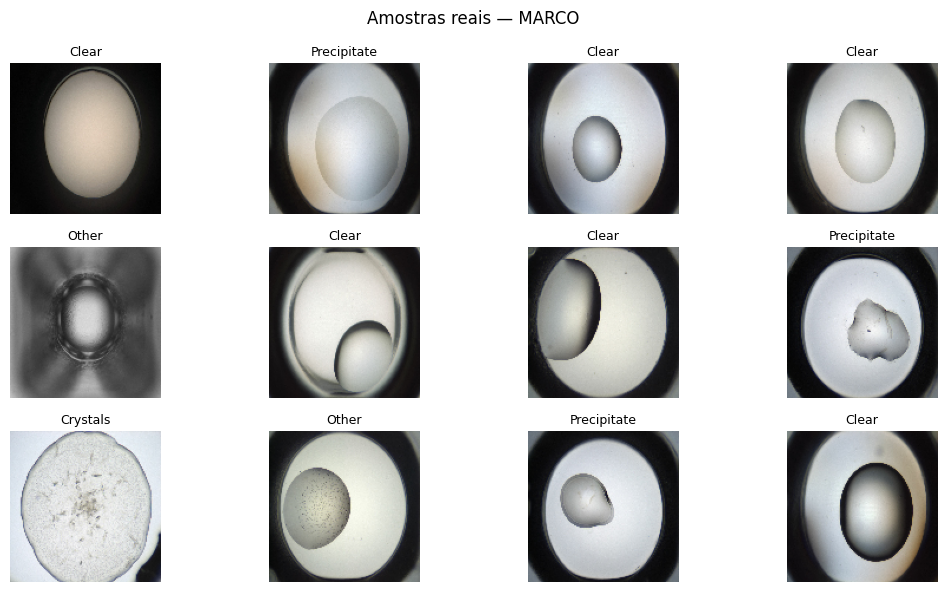

In [5]:
for x, y in ds_train.take(1):
    plt.figure(figsize=(11,6))
    for i in range(min(12, x.shape[0])):
        ax=plt.subplot(3,4,i+1); ax.imshow(x[i].numpy()); ax.axis('off')
        ax.set_title(CLASSES[int(y[i])], fontsize=9)
    plt.suptitle('Amostras reais — MARCO'); plt.tight_layout(); plt.show()

### 2.3 Pesos de classe **suaves** e data augmentation

O MARCO é desbalanceado. Na v2, pesos pelo inverso puro da frequência foram
**agressivos demais** e derrubaram o recall da classe majoritária (`Clear` caiu a
0,13). Aqui usamos a **raiz** do inverso da frequência (normalizada), que corrige o
desbalanceamento sem sabotar as classes grandes.

In [6]:
lbl_only = (tf.data.TFRecordDataset(trn_files).take(N_TRAIN)
            .map(lambda r: tf.io.parse_single_example(
                 r, {'image/class/label': tf.io.FixedLenFeature([], tf.int64)})['image/class/label'], num_parallel_calls=4))
cnt = collections.Counter(int(v) for v in lbl_only.as_numpy_iterator())
print('Distribuição (treino):', {CLASSES[i]: cnt.get(i,0) for i in range(len(CLASSES))})
total=sum(cnt.values()); K=len(CLASSES)
raw={i: math.sqrt(total/(K*cnt[i])) for i in cnt}          # peso SUAVE (raiz do inverso)
mean=sum(raw.values())/len(raw)
class_weight={i: raw[i]/mean for i in cnt}                 # normalizado p/ média ~1
print('class_weight (suave):', {k: round(v,2) for k,v in class_weight.items()})

data_aug = models.Sequential([layers.RandomFlip('horizontal_and_vertical'),
                              layers.RandomRotation(0.08), layers.RandomZoom(0.1)], name='aug')

Distribuição (treino): {'Clear': 3357, 'Crystals': 1295, 'Other': 591, 'Precipitate': 4997}
class_weight (suave): {3: 0.56, 1: 1.11, 0: 0.69, 2: 1.64}


## 3. CNNs treinadas do zero (sem modelos pré-treinados)

> **Decisão de arquitetura:** testamos `BatchNormalization`
> e observamos **instabilidade de convergência** (acurácia oscilando e caindo) neste
> cenário; por isso adotamos regularização por `Dropout` + augmentation, com
> `ReduceLROnPlateau` para refinar o aprendizado. Isso é uma escolha empírica
> documentada, não um descuido.

### CNN #1 — `CNN_Compacta` (3 blocos + Flatten)

In [7]:
def build_compacta():
    return models.Sequential([
        layers.Input((IMG,IMG,3)), layers.Rescaling(1./255), data_aug,
        layers.Conv2D(32,3,padding='same',activation='relu'), layers.MaxPool2D(),
        layers.Conv2D(64,3,padding='same',activation='relu'), layers.MaxPool2D(),
        layers.Conv2D(128,3,padding='same',activation='relu'), layers.MaxPool2D(),
        layers.Flatten(), layers.Dense(128,activation='relu'), layers.Dropout(0.3),
        layers.Dense(len(CLASSES),activation='softmax')], name='CNN_Compacta')
compacta=build_compacta()
compacta.compile(tf.keras.optimizers.Adam(1e-3),'sparse_categorical_crossentropy',metrics=['accuracy'])
compacta.summary()

Model: "CNN_Compacta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug (Sequential)                │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,196 (16.36 MB)

 Trainable params: 4,288,196 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
def callbacks():
    return [tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-5,verbose=1)]
hist_c = compacta.fit(ds_train,validation_data=ds_val,epochs=EPOCHS,class_weight=class_weight,callbacks=callbacks(),verbose=2)

Epoch 1/35


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


160/160 - 61s - 378ms/step - accuracy: 0.5087 - loss: 0.9509 - val_accuracy: 0.5342 - val_loss: 1.1050 - learning_rate: 0.0010
Epoch 2/35
160/160 - 73s - 457ms/step - accuracy: 0.5908 - loss: 0.8555 - val_accuracy: 0.6089 - val_loss: 0.9891 - learning_rate: 0.0010
Epoch 3/35
160/160 - 43s - 266ms/step - accuracy: 0.6149 - loss: 0.8185 - val_accuracy: 0.6738 - val_loss: 0.8962 - learning_rate: 0.0010
Epoch 4/35
160/160 - 43s - 266ms/step - accuracy: 0.6230 - loss: 0.7944 - val_accuracy: 0.6650 - val_loss: 0.8749 - learning_rate: 0.0010
Epoch 5/35
160/160 - 97s - 608ms/step - accuracy: 0.6375 - loss: 0.7770 - val_accuracy: 0.6030 - val_loss: 0.9477 - learning_rate: 0.0010
Epoch 6/35
160/160 - 44s - 273ms/step - accuracy: 0.6331 - loss: 0.7797 - val_accuracy: 0.5835 - val_loss: 1.0001 - learning_rate: 0.0010
Epoch 7/35

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
160/160 - 99s - 616ms/step - accuracy: 0.6541 - loss: 0.7553 - val_accuracy: 0.6348 - val_loss:

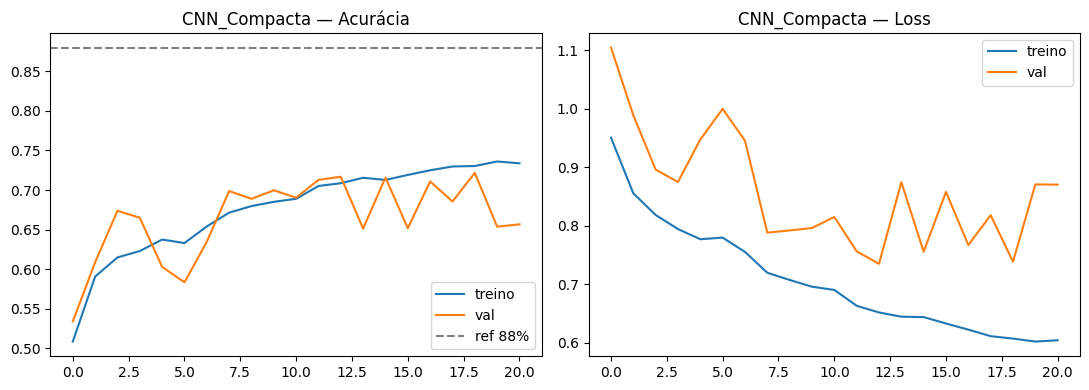

In [9]:
def plot_history(h,title):
    fig,ax=plt.subplots(1,2,figsize=(11,4))
    ax[0].plot(h.history['accuracy'],label='treino'); ax[0].plot(h.history['val_accuracy'],label='val')
    ax[0].axhline(0.88,ls='--',c='gray',label='ref 88%'); ax[0].set_title(f'{title} — Acurácia'); ax[0].legend()
    ax[1].plot(h.history['loss'],label='treino'); ax[1].plot(h.history['val_loss'],label='val')
    ax[1].set_title(f'{title} — Loss'); ax[1].legend(); plt.tight_layout(); plt.show()
plot_history(hist_c,'CNN_Compacta')

### CNN #2 — `CNN_Profunda` (blocos duplos + GlobalAveragePooling)
Mais blocos convolucionais (com convoluções duplas para extração de atributos mais
rica) e `GlobalAveragePooling`, o que a torna **mais profunda porém muito mais leve**
em parâmetros.

In [10]:
def build_profunda():
    return models.Sequential([
        layers.Input((IMG,IMG,3)), layers.Rescaling(1./255), data_aug,
        layers.Conv2D(32,3,padding='same',activation='relu'), layers.Conv2D(32,3,padding='same',activation='relu'), layers.MaxPool2D(),
        layers.Conv2D(64,3,padding='same',activation='relu'), layers.Conv2D(64,3,padding='same',activation='relu'), layers.MaxPool2D(),
        layers.Conv2D(128,3,padding='same',activation='relu'), layers.MaxPool2D(),
        layers.Conv2D(256,3,padding='same',activation='relu'), layers.MaxPool2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256,activation='relu'), layers.Dropout(0.5),
        layers.Dense(len(CLASSES),activation='softmax')], name='CNN_Profunda')
profunda=build_profunda()
profunda.compile(tf.keras.optimizers.Adam(1e-3),'sparse_categorical_crossentropy',metrics=['accuracy'])
profunda.summary()

Model: "CNN_Profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug (Sequential)                │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501,412 (1.91 MB)

 Trainable params: 501,412 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35
160/160 - 56s - 352ms/step - accuracy: 0.4861 - loss: 0.9603 - val_accuracy: 0.5322 - val_loss: 1.1431 - learning_rate: 0.0010
Epoch 2/35
160/160 - 44s - 276ms/step - accuracy: 0.5110 - loss: 0.9465 - val_accuracy: 0.5435 - val_loss: 1.1158 - learning_rate: 0.0010
Epoch 3/35
160/160 - 142s - 885ms/step - accuracy: 0.5086 - loss: 0.9340 - val_accuracy: 0.5435 - val_loss: 1.1974 - learning_rate: 0.0010
Epoch 4/35
160/160 - 91s - 567ms/step - accuracy: 0.5021 - loss: 0.9248 - val_accuracy: 0.5391 - val_loss: 1.1102 - learning_rate: 0.0010
Epoch 5/35
160/160 - 45s - 278ms/step - accuracy: 0.5085 - loss: 0.9130 - val_accuracy: 0.5420 - val_loss: 1.1238 - learning_rate: 0.0010
Epoch 6/35
160/160 - 44s - 274ms/step - accuracy: 0.5080 - loss: 0.9121 - val_accuracy: 0.4712 - val_loss: 1.1399 - learning_rate: 0.0010
Epoch 7/35
160/160 - 45s - 282ms/step - accuracy: 0.5105 - loss: 0.9094 - val_accuracy: 0.5068 - val_loss: 1.1063 - learning_rate: 0.0010
Epoch 8/35
160/160 - 44s - 274ms/

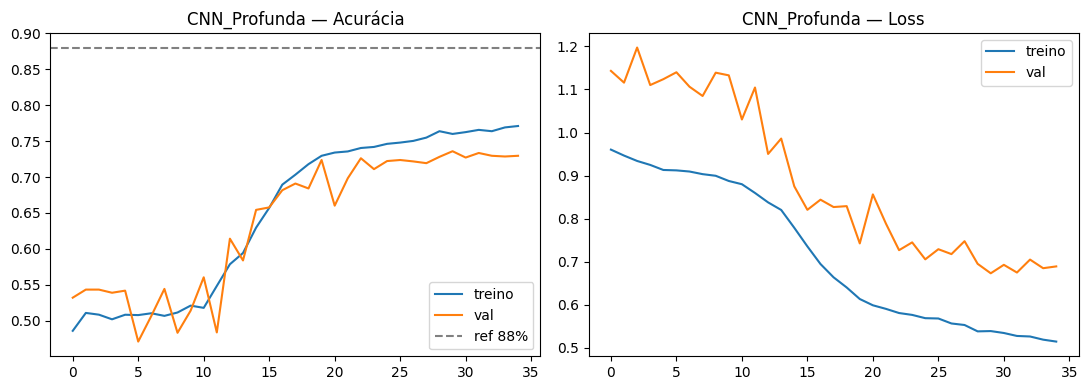

In [11]:
hist_p = profunda.fit(ds_train,validation_data=ds_val,epochs=EPOCHS,class_weight=class_weight,callbacks=callbacks(),verbose=2)
plot_history(hist_p,'CNN_Profunda')

## 4 e 5. Avaliação e comparação

In [12]:
y_te = np.concatenate([y.numpy() for _,y in ds_test])
def evaluate(model,name):
    pred=model.predict(ds_test,verbose=0).argmax(1)
    acc=accuracy_score(y_te,pred)
    base=max(np.bincount(y_te))/len(y_te)   # baseline trivial = maior classe
    print(f'\n===== {name} — acurácia de teste: {acc:.4f}  (baseline trivial={base:.3f}) =====')
    print(classification_report(y_te,pred,target_names=CLASSES,zero_division=0))
    return pred,acc
pred_c,acc_c=evaluate(compacta,'CNN_Compacta')
pred_p,acc_p=evaluate(profunda,'CNN_Profunda')


===== CNN_Compacta — acurácia de teste: 0.7103  (baseline trivial=0.476) =====
              precision    recall  f1-score   support

       Clear       0.69      0.92      0.79      1014
    Crystals       0.50      0.55      0.52       393
       Other       0.31      0.05      0.09       202
 Precipitate       0.82      0.70      0.75      1463

    accuracy                           0.71      3072
   macro avg       0.58      0.56      0.54      3072
weighted avg       0.70      0.71      0.69      3072


===== CNN_Profunda — acurácia de teste: 0.7490  (baseline trivial=0.476) =====
              precision    recall  f1-score   support

       Clear       0.80      0.90      0.85      1014
    Crystals       0.50      0.63      0.56       393
       Other       0.40      0.33      0.36       202
 Precipitate       0.84      0.73      0.78      1463

    accuracy                           0.75      3072
   macro avg       0.64      0.65      0.64      3072
weighted avg       0.76  

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


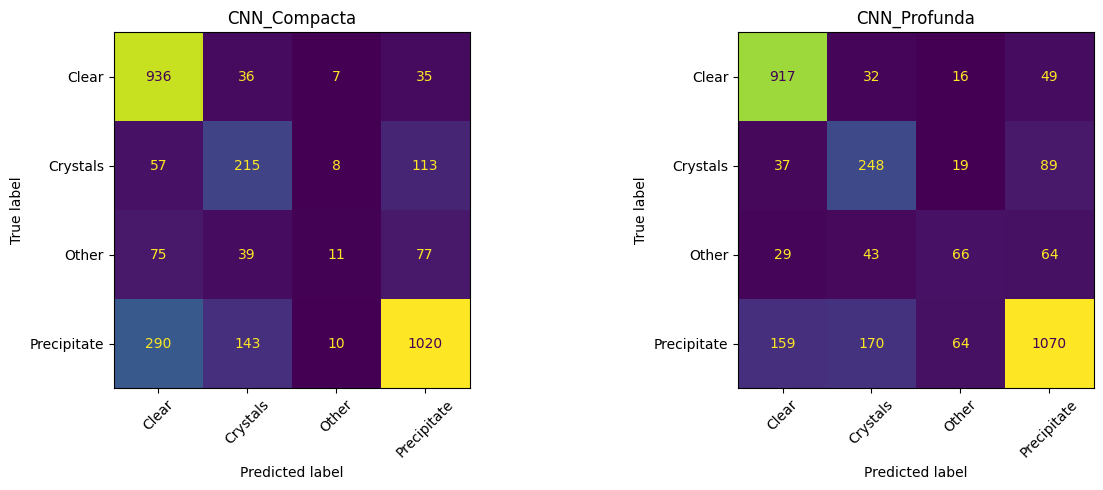

Resumo:  CNN_Compacta=0.710  |  CNN_Profunda=0.749


In [13]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
for a,(pred,name) in zip(ax,[(pred_c,'CNN_Compacta'),(pred_p,'CNN_Profunda')]):
    ConfusionMatrixDisplay(confusion_matrix(y_te,pred),display_labels=CLASSES).plot(ax=a,xticks_rotation=45,colorbar=False)
    a.set_title(name)
plt.tight_layout(); plt.show()
print(f'Resumo:  CNN_Compacta={acc_c:.3f}  |  CNN_Profunda={acc_p:.3f}')

CNN_Profunda: exibindo 8 exemplos classificados errado


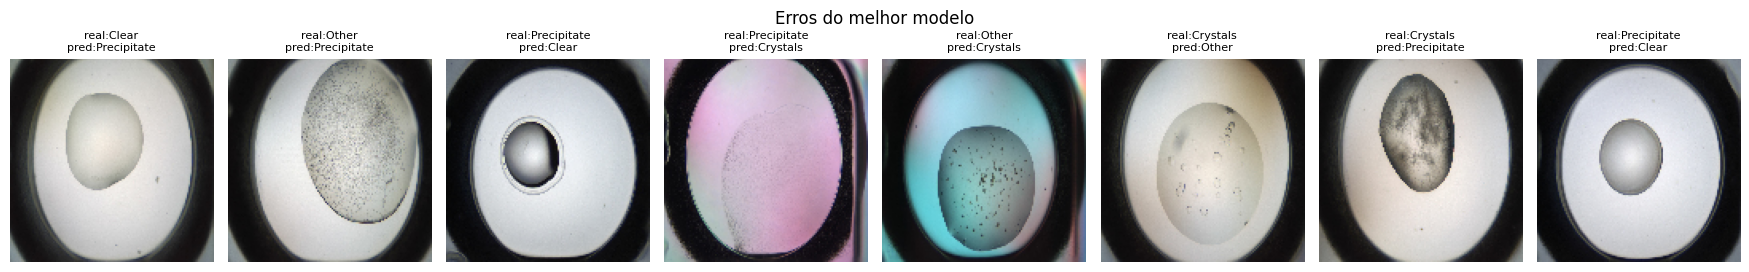

In [14]:
# Análise de erros (memória-segura: coleta só alguns exemplos errados, sem materializar todo o teste)
best, best_pred, best_name = (profunda,pred_p,'CNN_Profunda') if acc_p>=acc_c else (compacta,pred_c,'CNN_Compacta')
wrong_imgs=[]; wrong_txt=[]; i=0
for xb,yb in ds_test:
    pb=best.predict(xb,verbose=0).argmax(1); yb=yb.numpy()
    for j in range(len(yb)):
        if pb[j]!=yb[j] and len(wrong_imgs)<8:
            wrong_imgs.append(xb[j].numpy()); wrong_txt.append((CLASSES[yb[j]],CLASSES[pb[j]]))
    if len(wrong_imgs)>=8: break
print(f'{best_name}: exibindo {len(wrong_imgs)} exemplos classificados errado')
if wrong_imgs:
    n=len(wrong_imgs); plt.figure(figsize=(2.2*n,2.8))
    for i,(im,(r,p)) in enumerate(zip(wrong_imgs,wrong_txt)):
        ax=plt.subplot(1,n,i+1); ax.imshow(im); ax.axis('off'); ax.set_title(f'real:{r}\npred:{p}',fontsize=8)
    plt.suptitle('Erros do melhor modelo'); plt.tight_layout(); plt.show()

### 5.1 Discussão técnica


In [15]:
best.save('bio_orbit_acv_marco_best.keras')
size_mb=os.path.getsize('bio_orbit_acv_marco_best.keras')/1e6
sample=np.random.rand(1,IMG,IMG,3).astype('float32'); _=best.predict(sample,verbose=0)
t0=time.time(); [best.predict(sample,verbose=0) for _ in range(30)]; lat=(time.time()-t0)/30*1000
print(f'Melhor: {best_name} | params={best.count_params():,} | tamanho={size_mb:.1f} MB | latência≈{lat:.0f} ms/img')

Melhor: CNN_Profunda | params=501,412 | tamanho=6.1 MB | latência≈65 ms/img


## 6. Demonstração funcional (Gradio)

In [16]:
# !pip install gradio -q
import gradio as gr
from PIL import Image
def classify(img):
    g=np.array(Image.fromarray(img).convert('RGB').resize((IMG,IMG)),'float32')[None]  # 0-255; modelo normaliza
    p=best.predict(g,verbose=0)[0]
    return {CLASSES[i]: float(p[i]) for i in range(len(CLASSES))}
gr.Interface(classify, gr.Image(), gr.Label(num_top_classes=4),
             title='Bio-Orbit — Triagem de Cristalização (MARCO)',
             description='CNN treinada do zero classifica o resultado da gota de cristalização.').launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a8f4f9565d45a60a24.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Conclusão
Duas CNNs treinadas do zero classificam resultados **reais** de cristalização de
proteína, viabilizando a triagem visual a bordo e economizando banda de telemetria.
